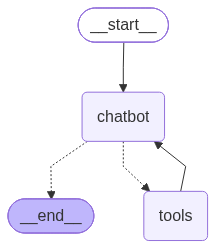

Sugar Bubbles bot ready. Type 'quit' to exit.

Bot: hey

Bot: Hey there! How can I help you with your Sugar Bubbles order today?

Bot: what are you selling?

Bot: {"cookies": {"box_of_4": 350, "box_of_6": 550, "flavors": ["Nutty Caramel Crunch ft Snickers", "Kitkat Crunch", "Cookies and Cream", "Classic Milk Chocolate", "Belgian Dark Chocolate", "Red Velvet", "Lotus Biscoff Crunch", "Choco Lava", "Choco Chunk", "Double Chocolate"]}, "brownies": {"box_of_3": 250, "box_of_6": 500, "flavors": ["Nutty Caramel", "Kitkat Crunch", "Cookies and Cream", "Classic Milk Chocolate", "Belgian Dark Chocolate", "Lotus Biscoff Crunch", "Choco Lava", "Choco Chunk", "Double Chocolate"]}, "brownie_tubs": {"price_350g": 450, "varieties": ["Kinder", "Kitkat", "Crunch Cake", "Cookie", "Chocolate Truffle"]}, "bento_cakes": {"weight": "250-300g", "starting_price": 400, "note": "Price varies by flavor/design — confirm exact price at order time."}, "cakes": {"vanilla": {"half_kg": 500, "one_kg": 1100}, "chocolat

In [ ]:
"""
Sugar Bubbles — Customer Chatbot (LangGraph)
=============================================

Architecture (4 tools, grouped by job — not one-function-per-tool):

1. menu_and_pricing        -> get_menu(), get_price(item, size)
2. order_builder           -> add_item_to_cart(state), view_cart(state)
3. validate_and_confirm    -> check_order_window(item_type), check_cake_notice(days_from_now),
                               get_order_summary(cart)
4. human_handoff           -> request_human_agent(reason)

Delivery rule (per your decision): the bot NEVER calculates an exact delivery
charge. It only tells the customer delivery happens the next day and that a
human agent will confirm the exact charge at dispatch time.

Run:
    pip install langgraph langchain-anthropic --break-system-packages
    export ANTHROPIC_API_KEY=...
    python sugar_bubbles_bot.py
"""

from __future__ import annotations
import datetime
from typing import Annotated, TypedDict, Literal

from langchain_core.tools import tool
from langchain_core.messages import SystemMessage
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

# ----------------------------------------------------------------------------
# 1. MENU DATA (single source of truth — tools only ever read from this)
# ----------------------------------------------------------------------------

MENU = {
    "cookies": {
        "box_of_4": 350,
        "box_of_6": 550,
        "flavors": [
            "Nutty Caramel Crunch ft Snickers", "Kitkat Crunch", "Cookies and Cream",
            "Classic Milk Chocolate", "Belgian Dark Chocolate", "Red Velvet",
            "Lotus Biscoff Crunch", "Choco Lava", "Choco Chunk", "Double Chocolate",
        ],
    },
    "brownies": {
        "box_of_3": 250,
        "box_of_6": 500,
        "flavors": [
            "Nutty Caramel", "Kitkat Crunch", "Cookies and Cream",
            "Classic Milk Chocolate", "Belgian Dark Chocolate",
            "Lotus Biscoff Crunch", "Choco Lava", "Choco Chunk", "Double Chocolate",
        ],
    },
    "brownie_tubs": {
        "price_350g": 450,
        "varieties": ["Kinder", "Kitkat", "Crunch Cake", "Cookie", "Chocolate Truffle"],
    },
    "bento_cakes": {
        "weight": "250-300g",
        "starting_price": 400,
        "note": "Price varies by flavor/design — confirm exact price at order time.",
    },
    "cakes": {
        "vanilla": {"half_kg": 500, "one_kg": 1100},
        "chocolate": {"half_kg": 600, "one_kg": 1300},
        "chocolate_truffle": {"half_kg": 700, "one_kg": 1500},
        "customized": "Charged per design — confirm with human agent.",
    },
}

ORDER_CUTOFF_HOUR = 16  # 4 PM same-day cutoff for cookies/brownies/tubs
CAKE_MIN_NOTICE_DAYS = 1


# ----------------------------------------------------------------------------
# 2. TOOL GROUP 1 — menu_and_pricing
# ----------------------------------------------------------------------------

@tool
def get_menu(category: Literal["cookies", "brownies", "brownie_tubs", "bento_cakes", "cakes", "all"] = "all") -> dict:
    """Return menu items and prices for a category, or the full menu if 'all'.
    Use this whenever a customer asks what's available or how much something costs.
    """
    if category == "all":
        return MENU
    return {category: MENU.get(category, "Category not found.")}


@tool
def get_price(item: str, size: str) -> dict:
    """Look up the exact price for a specific item + size/variant combination.
    item: one of 'cookies', 'brownies', 'brownie_tubs', 'bento_cakes', 'vanilla_cake',
          'chocolate_cake', 'chocolate_truffle_cake', 'customized_cake'
    size: e.g. 'box_of_4', 'box_of_6', '350g', 'half_kg', 'one_kg'
    Only return what this tool gives you — never state a price it did not return.
    """
    item = item.lower().strip()
    size = size.lower().strip()

    if item in ("cookies", "brownies"):
        price = MENU[item].get(size)
        return {"item": item, "size": size, "price": price} if price else {"error": "Size not found for this item."}

    if item == "brownie_tubs":
        return {"item": item, "size": "350g", "price": MENU["brownie_tubs"]["price_350g"]}

    if item == "bento_cakes":
        return {"item": item, "note": MENU["bento_cakes"]["note"], "starting_price": MENU["bento_cakes"]["starting_price"]}

    cake_map = {
        "vanilla_cake": "vanilla",
        "chocolate_cake": "chocolate",
        "chocolate_truffle_cake": "chocolate_truffle",
    }
    if item in cake_map:
        price = MENU["cakes"][cake_map[item]].get(size)
        return {"item": item, "size": size, "price": price} if price else {"error": "Size not found for this cake."}

    if item == "customized_cake":
        return {"item": item, "note": MENU["cakes"]["customized"]}

    return {"error": "Item not recognized. Ask the customer to clarify."}


# ----------------------------------------------------------------------------
# 3. TOOL GROUP 2 — order_builder
#    (Simple in-memory cart per conversation; in production, key this by
#    thread_id / customer_id and persist it properly.)
# ----------------------------------------------------------------------------

_CARTS: dict[str, list[dict]] = {}


@tool
def add_item_to_cart(thread_id: str, item: str, size: str, quantity: int, flavor: str = "") -> dict:
    """Add an item to the customer's current order/cart.
    thread_id identifies the conversation. Always confirm item + size + quantity
    (+ flavor if applicable) back to the customer after adding.
    """
    cart = _CARTS.setdefault(thread_id, [])
    entry = {"item": item, "size": size, "quantity": quantity, "flavor": flavor}
    cart.append(entry)
    return {"added": entry, "cart_item_count": len(cart)}


@tool
def view_cart(thread_id: str) -> dict:
    """Return everything currently in the customer's cart for this conversation."""
    return {"cart": _CARTS.get(thread_id, [])}


# ----------------------------------------------------------------------------
# 4. TOOL GROUP 3 — validate_and_confirm
# ----------------------------------------------------------------------------

@tool
def check_order_window(item_type: Literal["cookies", "brownies", "brownie_tubs"]) -> dict:
    """Check whether same-day ordering is still open for cookies/brownies/tubs.
    Cutoff is 4 PM same-day. Use before confirming these items.
    """
    now = datetime.datetime.now()
    open_ = now.hour < ORDER_CUTOFF_HOUR
    return {
        "item_type": item_type,
        "same_day_order_open": open_,
        "message": (
            "Order can be placed for today's dispatch."
            if open_
            else "Same-day cutoff (4 PM) has passed — this will be scheduled for the next available day."
        ),
    }


@tool
def check_cake_notice(requested_date: str) -> dict:
    """Check whether a requested cake date meets the 2-day minimum notice rule.
    requested_date format: 'YYYY-MM-DD'.
    """
    try:
        req = datetime.date.fromisoformat(requested_date)
    except ValueError:
        return {"error": "Invalid date format. Use YYYY-MM-DD."}

    min_date = datetime.date.today() + datetime.timedelta(days=CAKE_MIN_NOTICE_DAYS)
    ok = req >= min_date
    return {
        "requested_date": requested_date,
        "meets_minimum_notice": ok,
        "earliest_available_date": min_date.isoformat(),
        "message": (
            "This date works for a cake order."
            if ok
            else f"Cakes need at least {CAKE_MIN_NOTICE_DAYS} days' notice. Earliest available date is {min_date.isoformat()}."
        ),
    }


@tool
def get_order_summary(thread_id: str) -> dict:
    """Produce the final order summary for the customer to confirm.
    IMPORTANT: This never includes an exact delivery charge. It only states
    that delivery is the next day and that a human agent will confirm the
    exact delivery charge at dispatch time. Do not add any other delivery
    detail beyond what this tool returns.
    """
    cart = _CARTS.get(thread_id, [])
    if not cart:
        return {"error": "Cart is empty."}
    return {
        "items": cart,
        "delivery_note": (
            "Delivery will be the next day. The exact delivery charge will be "
            "confirmed by our team at the time of dispatch."
        ),
    }


# ----------------------------------------------------------------------------
# 5. TOOL GROUP 4 — human_handoff
# ----------------------------------------------------------------------------

@tool
def request_human_agent(reason: str) -> dict:
    """Escalate to a human agent — use for anything outside menu, ordering,
    cutoff/notice checks, or order summary (complaints, custom design requests,
    anything the customer explicitly asks a human for).
    """
    return {
        "handed_off": True,
        "reason": reason,
        "message": "A team member will reply shortly, usually within 30 minutes to 2 hours.",
    }


TOOLS = [
    get_menu, get_price,
    add_item_to_cart, view_cart,
    check_order_window, check_cake_notice, get_order_summary,
    request_human_agent,
]

# ----------------------------------------------------------------------------
# 6. GRAPH
# ----------------------------------------------------------------------------

class ChatState(TypedDict):
    messages: Annotated[list, add_messages]


SYSTEM_PROMPT = """You are the Sugar Bubbles bakery ordering assistant.

STRICT RULES — do not break these:
1. Only state facts that came from a tool result. Never invent prices, dates,
   delivery charges, confirmation emails, or timelines that no tool gave you.
2. For delivery, only ever say: delivery is the next day, and the exact
   delivery charge will be confirmed by a human agent at dispatch. Never
   compute or guess a delivery charge yourself.
3. If a request falls outside menu lookup, ordering, cutoff/notice checks,
   or order summary — call request_human_agent instead of answering yourself.
4. Always confirm item, size, quantity and flavor back to the customer after
   adding to cart.
5. Keep replies short and friendly, like a real bakery chat conversation.
"""
llm = ChatGroq(model="openai/gpt-oss-20b", temperature=0)
llm_with_tools = llm.bind_tools(TOOLS)


def chatbot_node(state: ChatState) -> dict:
    messages = state["messages"]
    if not any(isinstance(m, SystemMessage) for m in messages):
        messages = [SystemMessage(content=SYSTEM_PROMPT)] + messages
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}


graph_builder = StateGraph(ChatState)
graph_builder.add_node("chatbot", chatbot_node)
graph_builder.add_node("tools", ToolNode(TOOLS))

graph_builder.add_edge(START, "chatbot")
graph_builder.add_conditional_edges("chatbot", tools_condition)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge("chatbot", END)

memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)


# ----------------------------------------------------------------------------
# 7. SIMPLE CLI TEST LOOP (swap this for the FastAPI wrapper -> ManyChat later)
# ----------------------------------------------------------------------------

if __name__ == "__main__":
    thread_id = "test-customer-1"
    config = {"configurable": {"thread_id": thread_id}}
    print("Sugar Bubbles bot ready. Type 'quit' to exit.\n")
    while True:
        user_input = input("Customer: ")
        if user_input.lower() in ("quit", "exit"):
            break
        events = graph.stream(
            {"messages": [("user", user_input)]},
            config,
            stream_mode="values",
        )
        for event in events:
            last = event["messages"][-1]
            if hasattr(last, "content") and last.content:
                print(f"Bot: {last.content}\n")